# Assignment: EDA

## Exploratory Data Analysis using Visualization

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:/Users/abhij/Downloads/Titanic.csv")



In [4]:
# Basic exploration
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# Fill Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

C:\Users\abhij\AppData\Local\Temp\ipykernel_17056\292962150.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\abhij\AppData\Local\Temp\ipykernel_17056\292962150.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

#### Q1. Create a countplot to show the number of passengers by gender.

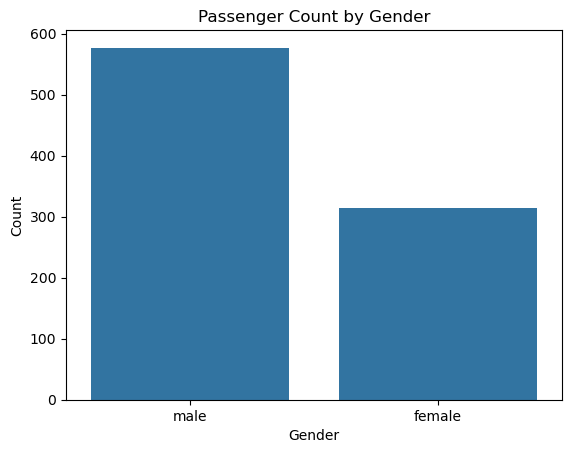

In [12]:
sns.countplot(x='Sex', data=df)
plt.title('Passenger Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

##### Interpretation:

##### *Typically more males than females onboard.
##### *Indicates gender imbalance in passengers.

#### Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.

C:\Users\abhij\AppData\Local\Temp\ipykernel_17056\3664153493.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='Set2')


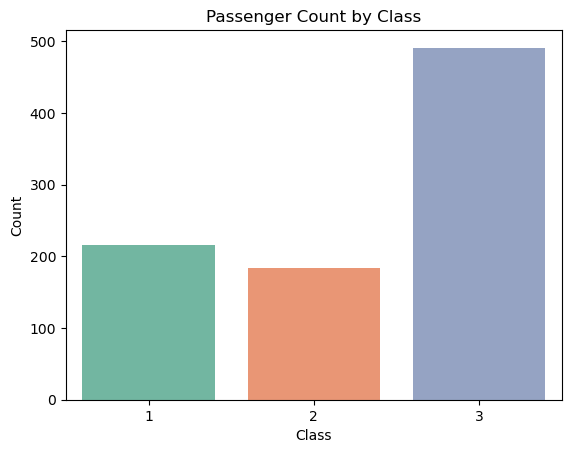

In [13]:
sns.countplot(x='Pclass', data=df, palette='Set2')
plt.title('Passenger Count by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

##### Interpretation:

##### *Most passengers are usually in 3rd class.
##### *Reflects socio-economic distribution.

#### Q3. Create a histogram to show the distribution of passenger age.

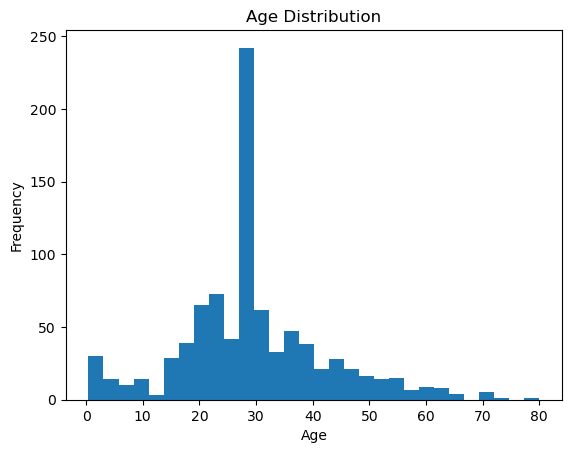

In [14]:
plt.hist(df['Age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

##### Interpretation:

##### *Majority fall in young adult range (20–40).
##### *Few elderly passengers

#### Q4. Create a boxplot to detect outliers in the fare column.

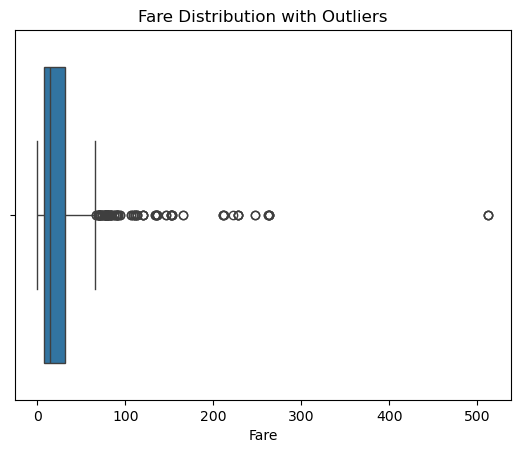

In [15]:
sns.boxplot(x=df['Fare'])
plt.title('Fare Distribution with Outliers')
plt.show()

##### Interpretation:

##### *Strong right skew.
##### *Presence of extreme high fares (outliers).

#### Q5. Create a scatterplot to 
##### a. show the relationship between age and fare.
##### b. analyze the relationship between family size (SibSp + Parch) and fare.

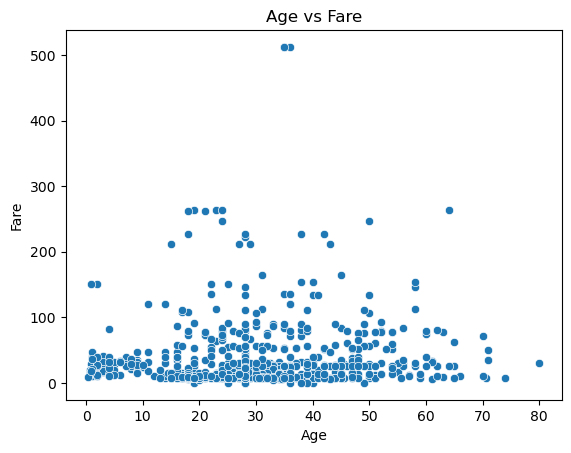

In [16]:
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title('Age vs Fare')
plt.show()

##### Interpretation:

##### *No strong correlation.
##### *Fare depends more on class than age.

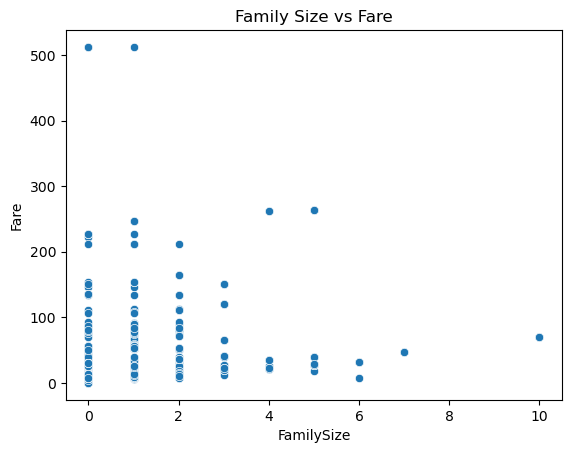

In [17]:
df['FamilySize'] = df['SibSp'] + df['Parch']

sns.scatterplot(x='FamilySize', y='Fare', data=df)
plt.title('Family Size vs Fare')
plt.show()

##### Interpretation:

##### *Slight trend: larger families may pay higher fares.
##### *But still weak correlation.

#### Q6. Create a countplot to show survival count by gender.

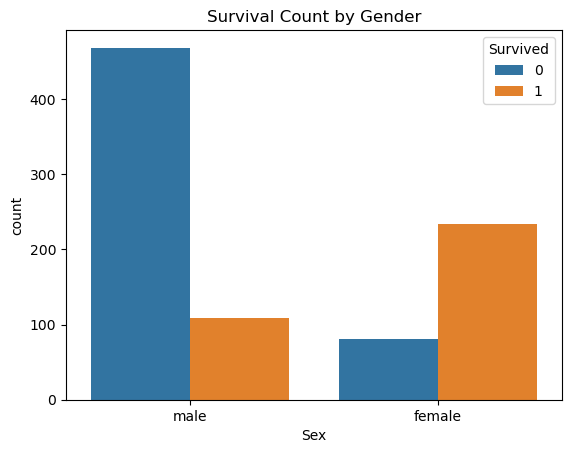

In [18]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Gender')
plt.show()

##### Interpretation:

##### *Females have much higher survival rate.
##### *“Women first” evacuation policy visible.

#### Q7. Create a bar chart to show survival by passenger class.

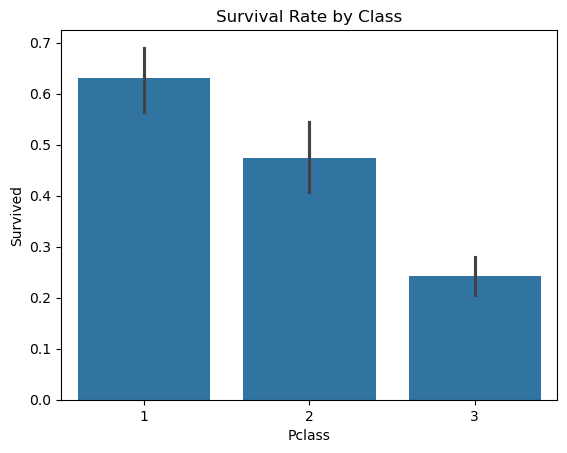

In [19]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.show()

##### Interpretation:

##### *1st class → highest survival
##### *3rd class → lowest survival
##### *Strong class-based inequality.

#### Q8. Create a heatmap to show correlation between numerical variables.

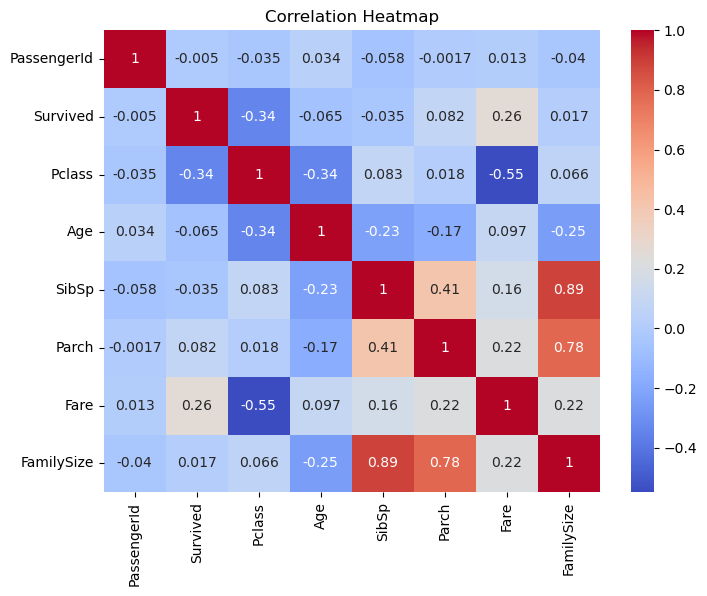

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### Interpretation:

##### *Fare and Pclass are negatively correlated.
##### *Survival correlates with class and fare.

#### Q9. Identify which passenger class paid the highest fare on average

In [22]:
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

##### 1st class passengers pay the highest average fare.

#### Q10. Write at least 5 insights from the dataset based on your visualizations.

Female passengers had significantly higher survival rates than males.
First-class passengers had better survival chances compared to lower classes.
The dataset shows a strong socio-economic divide affecting survival.
Most passengers were young adults between 20–40 years.
Fare distribution is highly skewed with extreme outliers.
Passenger class is a stronger predictor of survival than age.
Larger families show slight fare increase but weak correlation overall.